In [88]:
DISEASE = "BIPOLAR" # Default value
beta = 0.35 # Default value
average_t = [2, 4, 6, 8]

# Import

In [89]:
# ----------------------------
# Standard library
# ----------------------------
import json
import random
import os

# ----------------------------
# Core scientific stack
# ----------------------------
import numpy as np
import scipy.sparse as sp

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------
# Progress / memory profiling
# ----------------------------
from tqdm import tqdm
import gc



# Building Multilayer Transition Matrix

In [90]:
# Load all the matrices needed
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = "../../Gen_Hypergraph/output/MSigDB_Full/"

## DGIDB
DGIDB_binary_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
DGIDB_weighted_matrix = sp.load_npz(DGIDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
DGIDB_gene_weight_diag_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_gene_weight_matrix.npz")
DGIDB_diag_node_degree_matrix = sp.load_npz(DGIDB_DIRECTORY + "diag_node_degree_matrix.npz")
DGIDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    DGIDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

## MSIGDB
MSIGDB_binary_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_binary.npz")
MSIGDB_weighted_matrix = sp.load_npz(MSIGDB_DIRECTORY + "hypergraph_incidence_matrix_weighted.npz")
MSIGDB_gene_weight_diag_matrix = sp.load_npz(MSIGDB_DIRECTORY + "gene_weight_diag_matrix.npz")
MSIGDB_diag_node_degree_matrix = sp.load_npz(MSIGDB_DIRECTORY + "diag_node_degree_matrix.npz")
MSIGDB_inverse_diag_edge_degree_matrix = sp.load_npz(
    MSIGDB_DIRECTORY + "inverse_diag_edge_degree_matrix.npz"
    )

In [91]:
# Useful Functions
def csr_equal_tol(A, B, atol=1e-8):
    # First check shapes and sparsity pattern
    if A.shape != B.shape or not np.array_equal(A.indptr, B.indptr) or not np.array_equal(A.indices, B.indices):
        return False
    # Compare numeric values within tolerance
    return np.allclose(A.data, B.data, atol=atol, rtol=0)


# row stochastic check
def row_stochastic_check(A):
    row_sums = np.array(A.sum(axis=1)).ravel()
    print(row_sums)
    ok = np.all(np.isclose(row_sums, 1.0))
    print("Every row sums to 1?", ok)
    return ok

def is_symmetric(W,tol = 1e-12):
    diff = (W - W.T)
    if len(np.abs(diff.data)) == 0:
        print("Matrix is exactly symmetric.")
        return True
    else:
        check = np.all(np.abs(diff.data) < tol)
        print(max(np.abs(diff.data)))
    return check

def degree_array(A, a=1):
    return np.asarray(A.sum(axis=a)).ravel()

def degree_diagonal_matrix(W, a=1):
    d = degree_array(W,a)
    return sp.diags(d, offsets=0, format='csr')

def symmetrically_normalize(W, a=1):
    D = np.asarray(W.sum(axis=a)).ravel()
    D_inv_sqrt = np.zeros_like(D)
    nze = D != 0
    D_inv_sqrt[nze] = 1 / np.sqrt(D[nze])

    W_sym = W.multiply(D_inv_sqrt)              # scale columns
    W_sym = W_sym.multiply(D_inv_sqrt[:, None]) # scale rows    
    return W_sym.tocsr()

def big_objects(n=10, min_mb=1):
    """
    Show the largest objects currently in memory.
    
    Parameters
    ----------
    n : int
        Number of top objects to show.
    min_mb : float
        Minimum size (in MB) to include.
    """
    import sys
    import numpy as np
    import pandas as pd
    import scipy.sparse as sp
    from IPython import get_ipython

    def get_size(obj):
        try:
            if isinstance(obj, np.ndarray):
                return obj.nbytes
            elif isinstance(obj, pd.DataFrame) or isinstance(obj, pd.Series):
                return obj.memory_usage(deep=True).sum()
            elif sp.issparse(obj):
                return (obj.data.nbytes +
                        obj.indptr.nbytes +
                        obj.indices.nbytes)
            else:
                return sys.getsizeof(obj)
        except Exception:
            return 0

    ip = get_ipython()
    if ip is None:
        ns = globals()
    else:
        ns = ip.user_ns

    items = []
    for name, val in ns.items():
        if name.startswith('_'):
            continue  # skip internals
        size = get_size(val)
        if size > min_mb * 1024 ** 2:
            items.append((name, type(val).__name__, size))

    items.sort(key=lambda x: x[2], reverse=True)

    print(f"{'Variable':30s} {'Type':25s} {'Size (MB)':>10s}")
    print("-" * 70)
    for name, t, size in items[:n]:
        print(f"{name:30s} {t:25s} {size / 1024 ** 2:10.2f}")
        
def relative_normality_error(A):
    if sp.issparse(A):
        AH = A.getH()
        AAH = A @ AH
        AHA = AH @ A
        C = AAH - AHA

        num = np.sqrt(np.sum(np.abs(C.data)**2))
        den = max(
            np.sqrt(np.sum(np.abs(AAH.data)**2)),
            np.sqrt(np.sum(np.abs(AHA.data)**2)),
            1e-30
        )
        return num / den
    else:
        AH = A.conj().T
        AAH = A @ AH
        AHA = AH @ A
        return np.linalg.norm(AAH - AHA, 'fro') / max(
            np.linalg.norm(AAH, 'fro'),
            np.linalg.norm(AHA, 'fro'),
            1e-30
        )

In [92]:
# Building Adjacency Matrices

## DGIDB
H,W_v,D_v,D_e_inv, H_bin = DGIDB_weighted_matrix, DGIDB_gene_weight_diag_matrix, DGIDB_diag_node_degree_matrix, DGIDB_inverse_diag_edge_degree_matrix, DGIDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

DGIDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T



In [93]:
# ## MSIGDB
H,W_v,D_v,D_e_inv, H_bin = MSIGDB_weighted_matrix, MSIGDB_gene_weight_diag_matrix, MSIGDB_diag_node_degree_matrix, MSIGDB_inverse_diag_edge_degree_matrix, MSIGDB_binary_matrix

d = (D_v @ W_v).diagonal()
d_inv = np.zeros_like(d)
nonzero_mask = d > 0
d_inv[nonzero_mask] = 1.0 / d[nonzero_mask]
D_v_inv = sp.diags(d_inv)

MSIGDB_adjacency_matrix = D_v_inv @ H @ D_e_inv @ H.T

In [94]:
assert(row_stochastic_check(DGIDB_adjacency_matrix))
assert(row_stochastic_check(MSIGDB_adjacency_matrix))

[1.0000001  0.9999999  1.         1.         1.         1.0000001
 1.         0.9999999  1.         0.99999994 1.         1.
 1.         0.99999994 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999994 0.99999994 0.99999994 1.         1.
 0.99999994 1.0000001  0.99999994 1.         0.9999999  1.
 1.         1.         0.99999994 1.         1.         1.
 0.99999994 1.0000001  0.99999994 1.         1.         0.99999994
 1.         1.         1.         0.9999999  0.99999994 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.9999999  1.         1.0000001  0.9999998
 0.99999994 1.0000001  1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.9999999  1.         1.0000001  1.         1.         1.
 1.         0.99999994 1.         1.         0.99999994 1.
 1.         1.         0.99999994 0.99999994 1.         1.
 1.         1.         1.         

## coupling matrices

In [95]:
## Build interlayer coupling matrices between the two layers

dgidb_to_msigdb_indices = []
# Open the JSON file and load its content into a dictionary
with open(DGIDB_DIRECTORY + "gene_to_index.json", "r") as file:
    dgidb = json.load(file)
with open(MSIGDB_DIRECTORY + "gene_to_index.json", "r") as file:
    msigdb = json.load(file)
DGIDB_index_to_gene = {index: gene for gene, index in dgidb.items()}
MSIGDB_index_to_gene = {index: gene for gene, index in msigdb.items()}
MSIGDB_gene_to_index = {gene: index for gene, index in msigdb.items()}

num_genes_msigdb = len(msigdb)
num_genes_dgidb = len(dgidb)

# Intialize the inter-layer matrix with zeros
C12 = np.zeros((num_genes_dgidb,num_genes_msigdb))
C21 = np.zeros((num_genes_msigdb,num_genes_dgidb))
B12_array = np.zeros(num_genes_dgidb)
B21_array = np.zeros(num_genes_msigdb)

i = 0
for gene_dgidb, idx_dgidb in dgidb.items():
    # If the gene exists in both gene-to-index mappings
    if gene_dgidb in msigdb:      
        idx_msigdb = msigdb[gene_dgidb]
        dgidb_to_msigdb_indices.append((idx_dgidb, idx_msigdb))
        i += 1
    else:
        dgidb_to_msigdb_indices.append((idx_dgidb, None))
        print(f"Gene {gene_dgidb} not found in MSIGDB mapping.")
        
# build C21 and C12

for idx_dgidb, idx_msigdb in dgidb_to_msigdb_indices:
    if (idx_msigdb is not None):
        C12[idx_dgidb,:] = MSIGDB_adjacency_matrix.getrow(idx_msigdb).toarray().ravel()
        C21[idx_msigdb,:] = DGIDB_adjacency_matrix.getrow(idx_dgidb).toarray().ravel()
        B12_array[idx_dgidb] = beta
        B21_array[idx_msigdb] = beta

A12_array = 1 - B12_array
A21_array = 1 - B21_array

B12 = sp.diags(B12_array)
B21 = sp.diags(B21_array)
A12 = sp.diags(A12_array)
A21 = sp.diags(A21_array)
# print stat
print(i/len(dgidb), "of DGIDB genes have a match in MSIGDB")
dgidb_to_msigdb_indices_dict = dict(dgidb_to_msigdb_indices) 

Gene 360158 not found in MSIGDB mapping.
Gene 11 not found in MSIGDB mapping.
Gene 100302144 not found in MSIGDB mapping.
Gene 100302251 not found in MSIGDB mapping.
Gene 79529 not found in MSIGDB mapping.
Gene 236 not found in MSIGDB mapping.
Gene 652991 not found in MSIGDB mapping.
Gene 267012 not found in MSIGDB mapping.
Gene 693167 not found in MSIGDB mapping.
Gene 927 not found in MSIGDB mapping.
0.9721448467966574 of DGIDB genes have a match in MSIGDB


## Create gene to index ditinct

In [96]:
# build DGIDB_to_real
n1,n2 = num_genes_dgidb,num_genes_msigdb
# dgidb_to_real = []
dgidb_idx = []
gene_to_index_dgidb_new= {}
coupling_matrix = C12
msigdb_idx = np.arange(n1,n1+n2)
num_additional_rows = 0

for didx, midx in dgidb_to_msigdb_indices_dict.items():
    if(midx is None):
        # dgidb_to_real.append(didx)
        dgidb_idx.append(didx) 
        gene_to_index_dgidb_new[DGIDB_index_to_gene[didx]] = num_additional_rows
        num_additional_rows += 1
    # else: 
    #     dgidb_to_real.append(n1 + midx)
    
MSIGDB_gene_to_index_new = {g: i + num_additional_rows for g, i in msigdb.items()}
gene_to_index_distinct = MSIGDB_gene_to_index_new | gene_to_index_dgidb_new  
index_to_gene_distinct = {index: gene for gene, index in gene_to_index_distinct.items()}

In [97]:
for u, v in dgidb_to_msigdb_indices_dict.items():
    print(1) if v is None else None

1
1
1
1
1
1
1
1
1
1


## construct MTM

In [98]:
A = A12 @ DGIDB_adjacency_matrix
B = B12 @ C12
C = B21 @ C21
D = A21 @ MSIGDB_adjacency_matrix

In [99]:
## Build the multilayer transition matrix
P = sp.bmat([
    [A, B],
    [C, D]
]).tocsr()

num_genes = P.shape[0]
# del A, B, C, D, DGIDB_adjacency_matrix, MSIGDB_adjacency_matrix
# for i in range(3):
#     gc.collect()

# Select columns and rows of P using dgidb idx list and msigdb idx list

In [100]:
assert(row_stochastic_check(P))

[1.00000001 0.99999992 1.         ... 1.         1.         1.        ]
Every row sums to 1? True


## stationary distribution

In [101]:
def stationary_distribution(W, tol=1e-9, maxit=20000, seed=0):
    # power iteration for left stationary of row-stochastic W
    n = W.shape[0]
    rng = np.random.default_rng(seed)
    pi = rng.random(n) + 1e-12
    pi /= pi.sum()
    for _ in range(maxit):
        pi_next = pi @ W
        if np.linalg.norm(pi_next - pi, 1) < tol:
            break
        pi = pi_next
    return pi / pi.sum()

In [102]:
pi = stationary_distribution(P)

# Aggregation

## Column

In [75]:
num_distinct_row = len(gene_to_index_distinct)
# total number of columns being aggregated from M
total_cols = n1 + n2

rows = np.empty(total_cols, dtype=int)
cols = np.empty(total_cols, dtype=int)
data = np.ones(total_cols, dtype=P.dtype)

# DGIDB part
for k in range(n1):
    rows[k] = k
    cols[k] = gene_to_index_distinct[DGIDB_index_to_gene[k]]

# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]

# sparse grouping matrix
A_c = sp.csr_matrix((data, (rows, cols)), shape=(P.shape[1], num_distinct_row))

## Preparing Weights

In [76]:
dgidb_pi_average = pi[0:n1].mean()
msigdb_pi_average = pi[n1:n1+n2].mean()
print("Average stationary probability for DGIDB genes:", dgidb_pi_average)
print("Average stationary probability for MSIGDB genes:", msigdb_pi_average)
print("Ratio of averages (DGIDB/MSIGDB):", dgidb_pi_average / msigdb_pi_average)

Average stationary probability for DGIDB genes: 0.00041602558789561033
Average stationary probability for MSIGDB genes: 4.174636884566986e-05
Ratio of averages (DGIDB/MSIGDB): 9.965551481461665


In [77]:
pi

array([5.35920231e-05, 3.89918957e-08, 1.75662744e-04, ...,
       3.05219163e-10, 3.02877970e-10, 3.09411343e-10])

In [78]:
wD_list,wM_list = [], []
for u, v in dgidb_to_msigdb_indices_dict.items():
    if (v is not None):
        pid = pi[u]
        pim = pi[dgidb_to_msigdb_indices_dict[u] + n1]
        wd = pid / (pid + pim)
        wm = pim / (pid + pim)
        wD_list.append(wd)
        wM_list.append(wm)

## Row

In [79]:
wD_list2 = []
total_rows = n1 + n2

rows = np.empty(total_rows, dtype=int)
cols = np.empty(total_rows, dtype=int)
data = np.empty(total_rows, dtype=P.dtype)

# DGIDB part
for didx,midx in dgidb_to_msigdb_indices_dict.items():
    rows[didx] = didx
    cols[didx] = gene_to_index_distinct[DGIDB_index_to_gene[didx]]
    if (midx is None):
        data[didx] = 1.0
    else:
        wD = pi[didx] / (pi[didx] + pi[midx + n1])
        wD_list2.append(wD)
        data[didx] = wD

wM_list2_dict = {}
# MSIGDB part
for k in range(n2):
    rows[n1 + k] = n1 + k
    cols[n1 + k] = gene_to_index_distinct[MSIGDB_index_to_gene[k]]
    if (k in dgidb_to_msigdb_indices_dict.values()):
        # find the corresponding dgidb index
        corresponding_dgidb_idx = next(didx for didx, midx in dgidb_to_msigdb_indices_dict.items() if midx == k)
        wM = pi[n1 + k] / (pi[n1 + k] + pi[corresponding_dgidb_idx])
        wM_list2_dict[corresponding_dgidb_idx] = wM
        data[n1 + k] = wM
    else:
        data[n1 + k] = 1.0

# sparse grouping matrix
A_r = (sp.csr_matrix((data, (rows, cols)), shape=(P.shape[0], num_distinct_row))).T.tocsr()

In [80]:
wM_list2 = [wM_list2_dict[k] for k in sorted(wM_list2_dict)]

In [81]:
# Assert that the weights are computed the same as the graph
assert(wD_list == wD_list2 and wM_list == wM_list2)

# Gene Subsampling

In [82]:
# idx of all dgidb genes in the aggregated matrix
dgidb_agg_idx_list = [gene_to_index_distinct[DGIDB_index_to_gene[idx]] for idx in range(n1)]

In [ ]:
# # randomly sample num_sample genes to be tested
# num_sample_dgidb = 30
# num_sample_msigdb = 2000
# dgidb_idx_list = random.sample(range(DGIDB_adjacency_matrix.shape[0]), num_sample_dgidb)
# msigdb_idx_list = random.sample(range(MSIGDB_adjacency_matrix.shape[0]), num_sample_msigdb)
# print("Sampled DGIDB indices:", dgidb_idx_list)
# print("Sampled MSIGDB indices:", msigdb_idx_list)

Sampled DGIDB indices: [38, 90, 5, 106, 177, 189, 50, 54, 76, 44, 64, 46, 176, 197, 34, 192, 194, 155, 70, 94, 60, 196, 185, 3, 37, 141, 113, 123, 184, 103]
Sampled MSIGDB indices: [12401, 17569, 2507, 18828, 8802, 18719, 21746, 8299, 12315, 13106, 8385, 1464, 2228, 19615, 8948, 19991, 11312, 8381, 19084, 4101, 21693, 13828, 17633, 10245, 14981, 2833, 265, 10807, 12941, 19242, 15227, 18077, 13476, 11494, 10186, 3324, 6695, 4842, 10389, 6701, 3002, 10637, 12551, 11626, 2394, 4104, 21869, 21228, 12688, 2485, 7458, 14527, 1056, 9255, 3600, 11178, 16223, 20504, 11984, 8268, 8083, 21564, 9112, 4356, 11602, 16633, 17148, 7090, 16020, 9583, 6483, 17254, 1001, 6249, 4244, 18303, 8189, 7436, 1045, 3828, 5914, 8847, 3952, 16504, 4391, 5971, 10885, 9642, 11851, 21585, 10740, 410, 285, 11664, 12758, 8874, 5306, 6516, 17202, 11963, 3221, 20940, 1698, 12462, 6658, 5255, 7511, 15781, 14813, 8180, 222, 14163, 15768, 6522, 10576, 6130, 7202, 8316, 11734, 5797, 17005, 19723, 8219, 16784, 1061, 18813, 10

In [ ]:
# # make indices into aggregated indices and combine them
# dgidb_agg_idx_list = [gene_to_index_distinct[DGIDB_index_to_gene[idx]] for idx in dgidb_idx_list]
# msigdb_agg_idx_list = [gene_to_index_distinct[MSIGDB_index_to_gene[idx]] for idx in msigdb_idx_list]
# combined_agg_idx_list = set(dgidb_agg_idx_list) | set(msigdb_agg_idx_list)
# print("Sampled DGIDB aggregated indices:", dgidb_agg_idx_list)
# print("Sampled MSIGDB aggregated indices:", msigdb_agg_idx_list)
# print("Combined aggregated indices:", combined_agg_idx_list)

Sampled DGIDB aggregated indices: [1124, 2841, 158, 10591, 2162, 1675, 20205, 1615, 485, 5035, 1387, 2099, 5843, 16886, 1128, 3466, 2937, 5199, 5206, 7625, 1856, 4344, 3072, 3321, 425, 1137, 2037, 5266, 1870, 3996]
Sampled MSIGDB aggregated indices: [12404, 17572, 2510, 18831, 8805, 18722, 21749, 8302, 12318, 13109, 8388, 1467, 2231, 19618, 8951, 19994, 11315, 8384, 19087, 4104, 21696, 13831, 17636, 10248, 14984, 2836, 268, 10810, 12944, 19245, 15230, 18080, 13479, 11497, 10189, 3327, 6698, 4845, 10392, 6704, 3005, 10640, 12554, 11629, 2397, 4107, 21872, 21231, 12691, 2488, 7461, 14530, 1059, 9258, 3603, 11181, 16226, 20507, 11987, 8271, 8086, 21567, 9115, 4359, 11605, 16636, 17151, 7093, 16023, 9586, 6486, 17257, 1004, 6252, 4247, 18306, 8192, 7439, 1048, 3831, 5917, 8850, 3955, 16507, 4394, 5974, 10888, 9645, 11854, 21588, 10743, 413, 288, 11667, 12761, 8877, 5309, 6519, 17205, 11966, 3224, 20943, 1701, 12465, 6661, 5258, 7514, 15784, 14816, 8183, 225, 14166, 15771, 6525, 10579, 6133

In [ ]:
# # make sure combined lengths match
# print(len(combined_agg_idx_list))

2028


In [ ]:
# create folder if not exists
# os.makedirs(OUTPUT_DIRECTORY + "/beta_testing", exist_ok=True)

In [ ]:
# # Save combined indices to a JSON file
# with open(OUTPUT_DIRECTORY + "/beta_testing/combined_agg_idx_list.json", "w") as file:
#     json.dump(list(combined_agg_idx_list), file)

# Compute DGIDB genes profile

In [ ]:
dgidb_diffusion_profile = []

In [ ]:
# get selected rows of Ar P^t Ac for the sampled indices in a matrix free way through vector access
for idx in tqdm(dgidb_agg_idx_list):
    e = np.zeros(A_r.shape[0])
    e[idx] = 1.0

    idx_row = e @ A_r              # this is e_idx A_r
    avg_row = np.zeros(A_c.shape[1])

    current_t = 0

    for t in average_t:
        while current_t < t:
            idx_row = idx_row @ P  # reuse previous power
            current_t += 1
        avg_row += idx_row @ A_c   # this is e_idx A_r P^t A_c

    avg_row /= len(average_t)
    dgidb_diffusion_profile.append(avg_row)
    

In [ ]:
# Save resulting diffusion profiles to a npy file
dgidb_diffusion_profile = np.array(dgidb_diffusion_profile)
np.save(OUTPUT_DIRECTORY + f"/beta_testing/dgidb_diffusion_profile_{beta}.npy", dgidb_diffusion_profile)

# Avg distance to DGIDB genes for genes sampled

In [ ]:
def pairwise_squared_distances(S_profiles, D_profiles):
    S_profiles = np.asarray(S_profiles)
    D_profiles = np.asarray(D_profiles)

    S_norms = np.sum(S_profiles**2, axis=1)      # shape: (|S|,)
    D_norms = np.sum(D_profiles**2, axis=1)      # shape: (|D|,)

    D2 = (
        S_norms[:, None]
        + D_norms[None, :]
        - 2 * (S_profiles @ D_profiles.T)
    )

    # remove tiny negative values from floating-point error
    D2 = np.maximum(D2, 0.0)

    return D2

In [ ]:
# Load dgidb diffusion profile
dgidb_diffusion_profile = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dgidb_diffusion_profile_{beta}.npy")

In [ ]:
# Load the combined indices from the JSON file
with open(OUTPUT_DIRECTORY + "/beta_testing/combined_agg_idx_list.json", "r") as file:
    combined_agg_idx_list = json.load(file)

In [ ]:
sample_diffusion_profile = []

In [ ]:
# get selected rows of Ar P^t Ac for the sampled indices in a matrix free way through vector access
for idx in tqdm(combined_agg_idx_list):
    e = np.zeros(A_r.shape[0])
    e[idx] = 1.0

    idx_row = e @ A_r              # this is e_idx A_r
    avg_row = np.zeros(A_c.shape[1])

    current_t = 0

    for t in average_t:
        while current_t < t:
            idx_row = idx_row @ P  # reuse previous power
            current_t += 1
        avg_row += idx_row @ A_c   # this is e_idx A_r P^t A_c

    avg_row /= len(average_t)
    # print(f"Average distance to DGIDB genes for aggregated index {idx}: {avg_dgidb_diff_dist}")
    sample_diffusion_profile.append(avg_row)

In [ ]:
dist_matrix = pairwise_squared_distances(sample_diffusion_profile, dgidb_diffusion_profile)
print(dist_matrix.shape)

In [ ]:
# Convert the resulting list to nparray and save to a npy file
np.save(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_{beta}.npy", dist_matrix)

# Computing R

In [103]:
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"

In [104]:
# Load D_avg_beta_array from the npy file
beta_list = [0.0, 0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7,0.8,0.9]
D_baseline = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_0.0.npy")
D_baseline_avg = D_baseline.mean(axis=1)
R_matrix = []
D_beta_dict = {}

In [105]:
for beta in beta_list[1:]:
    D_beta = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_{beta}.npy")
    D_beta_avg = D_beta.mean(axis=1)
    D_beta_dict[beta] = D_beta_avg
    
    positive_vals = np.concatenate([D_baseline_avg, D_beta_avg]) 
    eps = 1e-8 * np.median(positive_vals)
    
    R = np.log10((D_beta_avg + eps) / (D_baseline_avg + eps))
    R_matrix.append(R)

In [106]:
# setting universal font sizes
font_size = 20
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": tick_font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": 14,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


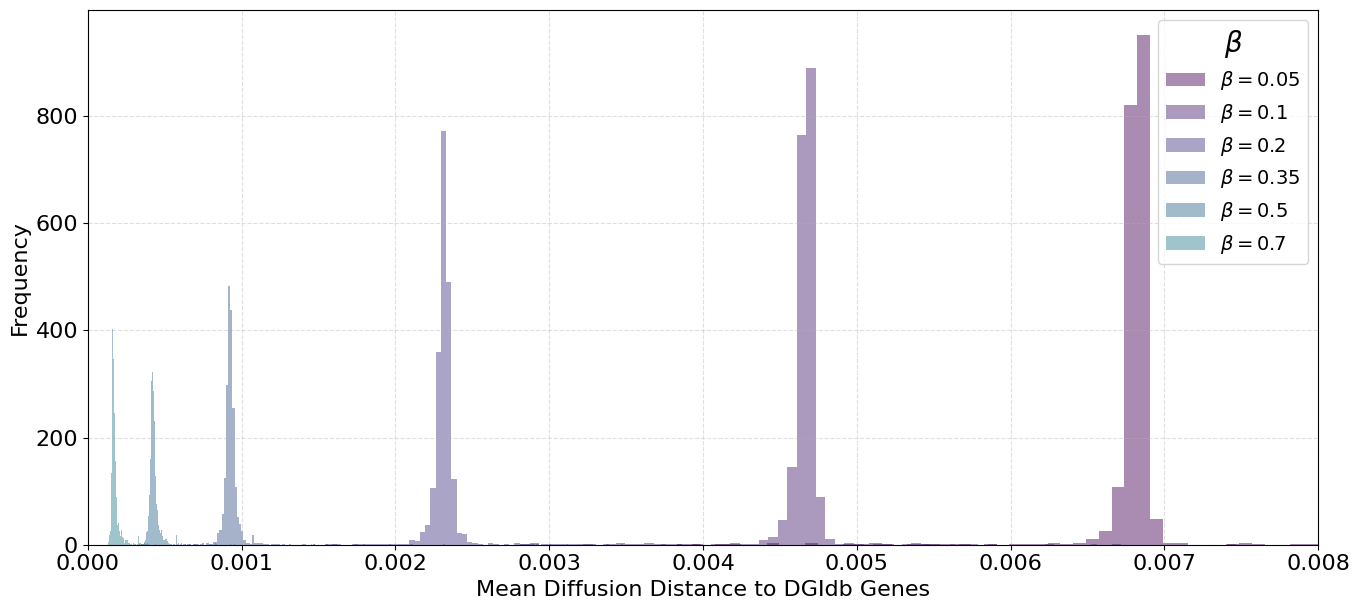

In [109]:
colors = plt.cm.viridis(np.linspace(0, 1, len(beta_list)))  # ADDED: one color per beta

plt.figure(figsize=(14, 6.5))

for i, beta in enumerate(beta_list[5:-2]):
    plt.hist(
        D_beta_dict[beta],      # MODIFIED: values for this beta
        bins=200,             # ADDED: histogram bin count
        color=colors[i],     # ADDED: unique color for this beta
        alpha=0.45,          # ADDED: transparency so overlaps are visible
        label=fr"$\beta={beta}$"
    )

plt.xlabel("Mean Diffusion Distance to DGIdb Genes")  # MODIFIED: replace with your x-axis label
plt.ylabel("Frequency")  # MODIFIED: replace with your y-axis label

# cap x-axis to 0.01
plt.xlim(0, 0.008)
plt.legend(title=r"$\beta$")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/diffusion_distance_distribution_comparison.pdf", dpi=300)
plt.show()
plt.close()

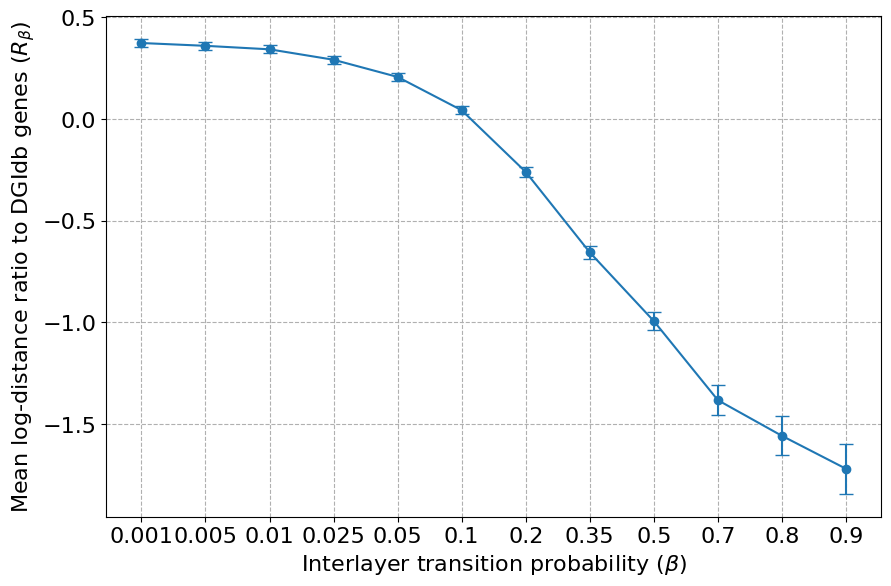

In [108]:
# Plot mean and standard deviation of R for each beta
R_matrix = np.array(R_matrix)

mean_R = R_matrix.mean(axis=1)
median_R = np.median(R_matrix, axis=1)

std_R = R_matrix.std(axis=1)

# # ADDED: compute sample size per beta
# num_sample = R_matrix.shape[1]

# # ADDED: compute standard error
# se_R = std_R / np.sqrt(num_sample)

x_pos = np.arange(len(beta_list[1:]))

plt.figure(figsize=(10, 6.5))

# USE STANDARD ERROR instead of std
plt.errorbar(x_pos, mean_R, yerr=std_R, fmt='o-', capsize=5)

plt.xlabel(r"Interlayer transition probability ($\beta$)")
plt.ylabel(r"Mean log-distance ratio to DGIdb genes ($R_{\beta}$)")

plt.xticks(x_pos, [str(b) for b in beta_list[1:]])

plt.grid(True, which="both", ls="--")

plt.savefig(f"../../Graphs/{DISEASE}/beta_sensitivity.pdf", dpi=300)
plt.show()
plt.close()

# Diagnostics

In [ ]:
# # Load the combined indices from the JSON file
# with open(OUTPUT_DIRECTORY + "/beta_testing/combined_agg_idx_list.json", "r") as file:
#     combined_agg_idx_list = json.load(file)

In [ ]:
# D_beta = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_{0.35}.npy")

## dgidb diffusion profile check

In [ ]:
# P_t_avg = np.load(f"../output/{DISEASE}/P_t_avg.npy")

In [ ]:
# P_t_avg_dgidb = P_t_avg[dgidb_agg_idx_list,:]

In [ ]:
# P_t_avg_dgidb

In [ ]:
# Load dgidb diffusion profile
# dgidb_diffusion_profile = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dgidb_diffusion_profile_{beta}.npy")

In [ ]:
# dgidb_diffusion_profile

## ddm check

In [ ]:
# D_beta

In [ ]:
# D_avg_actual_baseline = np.load(f"../output/NONE/ddm_[2, 4, 6, 8].npy")

In [ ]:
# D_avg = np.load(f"../output/{DISEASE}/ddm_[2, 4, 6, 8].npy")

In [ ]:
# D_avg

In [ ]:
# D_avg_selected  = D_avg[combined_agg_idx_list,:]
# D_avg_selected = D_avg_selected[:,dgidb_agg_idx_list]

In [ ]:
# D_avg_selected

## comparison plot

In [ ]:
# D_avg_actual_baseline.mean()

In [ ]:
# D_baseline = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_0.0.npy")
# D_baseline_avg = D_baseline.mean(axis=1)

In [ ]:
# D_baseline_avg.mean()

In [ ]:
# D_beta_avg = D_beta.mean(axis=1)

In [ ]:
# D_beta_avg

In [ ]:
# D_actual_avg = D_avg_selected.mean(axis=1)

In [ ]:
# D_actual_avg

In [ ]:
# # DGIDB rows comparing to all genes
# xaxis = range(len(D_actual_avg))
# plt.figure(figsize=(10, 6))
# plt.scatter(xaxis, D_baseline_avg, label='Single-layer', color='orange')
# plt.scatter(xaxis, D_actual_avg, label='Multilayer', color='blue')
# plt.yscale('log')
# # legend placed outside of plot
# plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')